In [2]:
%load_ext autoreload
%autoreload 3

### Carrgando modelos

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM

In [5]:
# ============================= Carregando modelo ============================

models = ["Qwen/Qwen3-0.6B", "Qwen/Qwen3-4B-Instruct-2507"]
model_name = models[0]

llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype="auto",
    device_map="auto",
    trust_remote_code=True # Recomendado para modelos Qwen/comunidade
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [4]:
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from config.paths import VECTOR_STORE

In [5]:
def load_vectorstore(model_name="Qwen/Qwen3-Embedding-0.6B", device='cpu'):
    path = VECTOR_STORE
    encoder = SentenceTransformer(model_name, device=device)
    client = QdrantClient(path=VECTOR_STORE) # Carrega vectorstore em disco

    return encoder, client

encoder, client = load_vectorstore(device='cuda')

Loading weights: 100%|██████████| 310/310 [00:00<00:00, 2177.32it/s]
/tmp/ipykernel_111217/3675847706.py:4: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Collection <Recurso_metadados> contains 63190 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  client = QdrantClient(path=VECTOR_STORE) # Carrega vectorstore em disco


In [1]:
import uuid
from chatbot.llm import LLML, LLM
from config.paths import MODELOS

llm_wrapper=LLML(model_path=str(MODELOS['Qwen3-4B-Instruct-2507-UD-Q4_K_XL']),
                                n_gpu_layers=-1, verbose=False, n_ctx=4096,)

/home/migueldcarvalho/miniforge3/envs/geral/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/migueldcarvalho/miniforge3/envs/geral/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
llama_context: n_ctx_per_seq (4096) < n_ctx_train (262144) -- the full capacity of the model will not be utilized


In [4]:
from config.paths import TOOLS, SYSTEM_PROMPTS
from chatbot.utils import read_yaml

pad = read_yaml(TOOLS)['BluePrint']
tools_description = read_yaml(TOOLS)['tools']
#tools = tools_description#['tabular_query']
tools = []
for tool in tools_description.values():
    tools.append(tool)

system = read_yaml(path=SYSTEM_PROMPTS)['system_prompt_tools']['v1']

messages = [{'role': 'system', 'content': system}, 
            {'role': 'user', 'content': 'pesquise sobre doenças endemicas'}]
llm_wrapper.create_chat_completion(messages=messages, tools=[tools[0]])

{'id': 'chatcmpl-414ebbdd-8b22-4c25-a736-75c488876567',
 'object': 'chat.completion',
 'created': 1773159599,
 'model': '/home/migueldcarvalho/Projetos/Chatbot/modelos_locais/Qwen3-4B-Instruct-2507-UD-Q4_K_XL.gguf',
 'choices': [{'index': 0,
   'message': {'role': 'assistant',
    'content': '<tool_call>{"name": "answering_question", "arguments": {"query": "doenças endêmicas"}}</tool_call>'},
   'logprobs': None,
   'finish_reason': 'stop'}],
 'usage': {'prompt_tokens': 356, 'completion_tokens': 25, 'total_tokens': 381}}

In [59]:
tools[0]

{'type': 'function,',
 'function': {'name': 'answering_question',
  'description': 'Busca por dados no banco de dados brasileiro, responde perguntas referentes a saúde, criminalidade, programas sociais...',
  'parameters': {'type': 'object',
   'required': ['query'],
   'properties': {'query': {'type': 'string',
     'description': 'Assunto requisitado pelo usuário'}}}}}

## Testes

In [7]:
from langchain_core.messages import BaseMessage   # Classe pai que dá origem a todos os tipos de messagem no langchain
from langchain_core.messages import ToolMessage   # Classe que gerencia messagens/respotas das tools
from langchain_core.messages import HumanMessage
from langchain_core.messages import AIMessage
from langchain_core.messages import SystemMessage 

from icecream import ic

def role(message: BaseMessage)-> str:
    if isinstance(message, HumanMessage):
        return "user"
    else:
        return "assistant"

def show_messages(messages: list)-> None:
    
    for message in messages:
        if isinstance(message, AIMessage):
            ic(message.content)
        elif isinstance(message, ToolMessage):
            ic(message.content)
        elif isinstance(message, HumanMessage):
            ic(message.content)
        elif isinstance(message, SystemMessage):
            ic(message.content)
        else:
            ic(f"Não é uma BaseMessage: {type(message)} {message}")

In [9]:
import uuid
from chatbot.llm import LLML, LLM
from config.paths import MODELOS
from chatbot.graph import chat_graph

def transformer_config():
    llm_model = AutoModelForCausalLM.from_pretrained(llm_model_name, device_map="auto", dtype='auto')
    #= AutoModelForCausalLM().from_pretrained(llm_model_name, device_map="auto", dtype='auto', trust_remote_code=True)
    tokenizer = AutoTokenizer.from_pretrained(llm_model_name)
    encoder, client = load_vectorstore()


    return {'configurable': {
            'thread_id': uuid.uuid4(),
            'llm': llm_model, 
            'tokenizer': tokenizer,
            'llm_wrapper': LLM(model=llm_model, tokenizer=tokenizer),
            'encoder': encoder,
            'client': client
            }}
    
def llama_config():
    #encoder, client = load_vectorstore()
    return {'configurable': {
            'thread_id': uuid.uuid4(),
            'llm': 'llm_model', 
            'tokenizer': 'tokenizer',
            'llm_wrapper': llm_wrapper,
            'encoder': encoder,
            'client': client
            }}


from langgraph.types import Command

config = llama_config()

def interativo():
    graph = chat_graph()

    prompt = "Olá"
    while prompt != 'quit':
        for chunk in graph.stream({'messages': [prompt]}, config, stream_mode='messages'):
            messages.append(chunk)
        show_messages(messages)
        prompt = input("User> ")

queries = [
        ["Qual estado possui a maior quantidade de multas ambientais?"],

        
        ["Qual é o preço de tarifas de exportação e produtos eletronicos?",
        "Quantos pessoas nasceram em 2024?"]]

prompts = ["Olá", queries[0][0]]

def testes():
    messages = []

    graph = chat_graph()

    for chunk in graph.stream({'messages': [prompts[0]]}, config, stream_mode='messages'):
        messages.append(chunk[0])
    print(prompts[0])
    for prompt in prompts[1:]:
        print(prompt)
        command = Command(resume=prompt)
        for chunk in graph.stream(command, config, stream_mode='messages'):
            messages.append(chunk[0])
    
    return messages, graph.get_state(config)
    
    #show_messages(messages)
        
messages, graph_state = testes()
show_messages(messages)

ic| 'Inicializando...'


================================================== Tempo de execução ==================================================
Tempo de execução: 9.345415969000896

Olá
Qual estado possui a maior quantidade de multas ambientais?


ic| response: AIMessage(content='Olá! Como posso ajudar você hoje? 😊', additional_kwargs={'thinking': None}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])


================================================== Tempo de execução ==================================================
Tempo de execução: 4.058852564980043



ic| response: AIMessage(content='<tool_call>
              {"name": "answering_question", "arguments": {"query": "qual estado possui a maior quantidade de multas ambientais"}}
              </tool_call>', additional_kwargs={'thinking': None}, response_metadata={}, tool_calls=[{'name': 'answering_question', 'args': {'query': 'qual estado possui a maior quantidade de multas ambientais'}, 'id': 'call_ba3970c5', 'type': 'tool_call'}], invalid_tool_calls=[])
ic| f"teste {link}": 'teste https://dadosabertos.ibama.gov.br/dados/SICAFI/AC/Quantidade/multasDistribuidasBensTutelados.html'
ic| f"Formato {format} não suportado": 'Formato HTML não suportado'
ic| f"teste {link}": 'teste http://dadosabertos.ibama.gov.br/dados/SICAFI/AC/Quantidade/multasDistribuidasBensTutelados.csv'
ic| 'pre-análise concluida...'


================================================== Tempo de execução ==================================================
Tempo de execução: 41.350756029976765



ic| 'Codigo gerado'
ic| 'DataFrame carregado'
ic| code: '''<code>
           SELECT UF, COUNT(*) AS quantidade_multas
           FROM dt_table
           WHERE 'Tipo Infração' = 'Flora'
           GROUP BY UF
           ORDER BY quantidade_multas DESC
           LIMIT 1;
           </code>'''
ic| dataframe: Empty DataFrame
               Columns: [UF, quantidade_multas]
               Index: []
ic| f"teste {link}": 'teste https://dadosabertos.ibama.gov.br/dados/SICAFI/AC/Quantidade/multasDistribuidasBensTutelados.xml'
ic| f"Formato {format} não suportado": 'Formato XML não suportado'
ic| 'answering_question concluido'
ic| results: {'tabular_data': Empty DataFrame
             Columns: [UF, quantidade_multas]
             Index: []}


NotImplementedError: Unsupported message type: <class 'pandas.core.frame.DataFrame'>
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/MESSAGE_COERCION_FAILURE 

In [21]:
from pandasql import sqldf
import pandas as pd
from chatbot.tools.utils import encoding_type, GovPath

link = "http://dadosabertos.ibama.gov.br/dados/SICAFI/AC/Quantidade/multasDistribuidasBensTutelados.csv"
#link = "https://aplicacoes.mds.gov.br/sagi/servicos/misocial?fq=anomes_s:2016*&fq=tipo_s:mes_mu&wt=csv&q=*&fl=ibge:codigo_ibge,anomes:anomes_s,qtd_familias_beneficiarias_bolsa_familia,valor_repassado_bolsa_familia&rows=10000000&sort=anomes_s%20asc,%20codigo_ibge%20asc"

paths = GovPath(link)

sql_query ='''

SELECT UF, COUNT(*) AS quantidade_multas
FROM dt_table
WHERE "Tipo Infração" = 'Flora'
GROUP BY UF
ORDER BY quantidade_multas DESC
LIMIT 1;
'''

dt_table = pd.read_csv(paths.datapath, encoding=encoding_type(paths.datapath), on_bad_lines='skip', sep=';', decimal=',')
res = sqldf(sql_query, {'dt_table': dt_table})
res

,UF,quantidade_multas
0,AC,9255


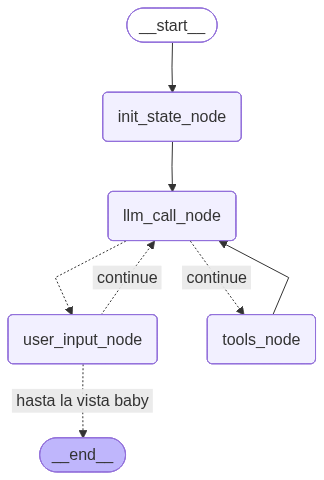

In [ ]:
graph